# Le due Italie — divario Nord-Sud multi-dimensionale

Dataset: eurostat_gdp_nuts3, eurostat_poverty_risk_nuts2, eurostat_physicians_nuts2, eurostat_hospital_beds_nuts2, eurostat_pop_structure_nuts3

Vedi README: [../README.md](../README.md)

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

# GCS paths — ogni parquet contiene tutti gli anni
GCS = "https://storage.googleapis.com/dataciviclab-clean/eurostat"
YEAR = "2026"  # year fittizio (il TSV contiene tutti gli anni)

def p(slug):
    return f"{GCS}/{slug}/{slug}_{YEAR}_clean.parquet"

FIGS = Path("../figures")
FIGS.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute("SET threads=1")
con.execute("SET allow_asterisks_in_http_paths=true")

# Palette Lab
BLUE = '#2c3e50'
GREEN = '#27ae60'
RED = '#e74c3c'
GRAY = '#95a5a6'

### 1. GDP trend Nord vs Sud (2000-2024)

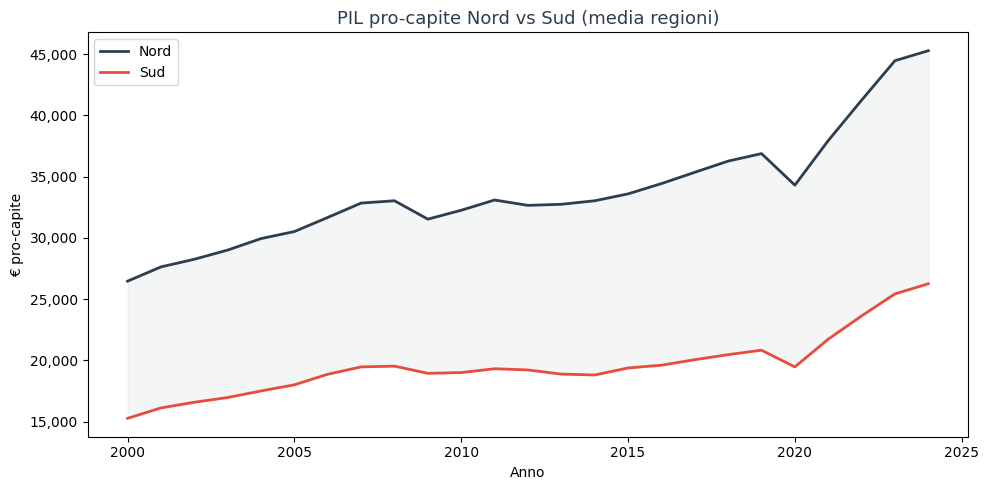

Gap 2000: 11,200€ → 2024: 19,025€


In [2]:
north = ["Piemonte","Lombardia","Liguria","Veneto","Emilia-Romagna","Friuli-Venezia Giulia",
         "Provincia Autonoma di Trento","Provincia Autonoma di Bolzano/Bozen","Valle d'Aosta"]
south = ["Abruzzo","Molise","Campania","Puglia","Basilicata","Calabria","Sicilia","Sardegna"]

df = con.execute(f"""
    SELECT geo_label_en, year, value
    FROM read_parquet('{p('eurostat_gdp_nuts3')}')
    WHERE unit='EUR_HAB' AND nuts_level='NUTS2' AND geo LIKE 'IT%'
      AND year >= 2000 AND year <= 2024
""").fetchdf()

df['area'] = df['geo_label_en'].apply(lambda x: 'Nord' if x in north else ('Sud' if x in south else 'Centro'))
trend = df[df['area'].isin(['Nord','Sud'])].groupby(['year','area'])['value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for area, color in [('Nord', BLUE), ('Sud', RED)]:
    d = trend[trend['area']==area]
    ax.plot(d['year'], d['value'], color=color, linewidth=2, label=area)
ax.fill_between(trend[trend['area']=='Nord']['year'],
                trend[trend['area']=='Sud']['value'].values,
                trend[trend['area']=='Nord']['value'].values,
                alpha=0.1, color=GRAY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Anno'); ax.set_ylabel('€ pro-capite')
ax.set_title('PIL pro-capite Nord vs Sud (media regioni)', fontsize=13, color=BLUE)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS/'divario-nord-sud_gdp_trend.png', dpi=150, bbox_inches='tight')
plt.show()
g_start = trend[trend['area']=='Nord']['value'].values[0]-trend[trend['area']=='Sud']['value'].values[0]
g_end = trend[trend['area']=='Nord']['value'].values[-1]-trend[trend['area']=='Sud']['value'].values[-1]
print(f"Gap 2000: {g_start:,.0f}€ → 2024: {g_end:,.0f}€")

### 2. Povertà regionale (2024)

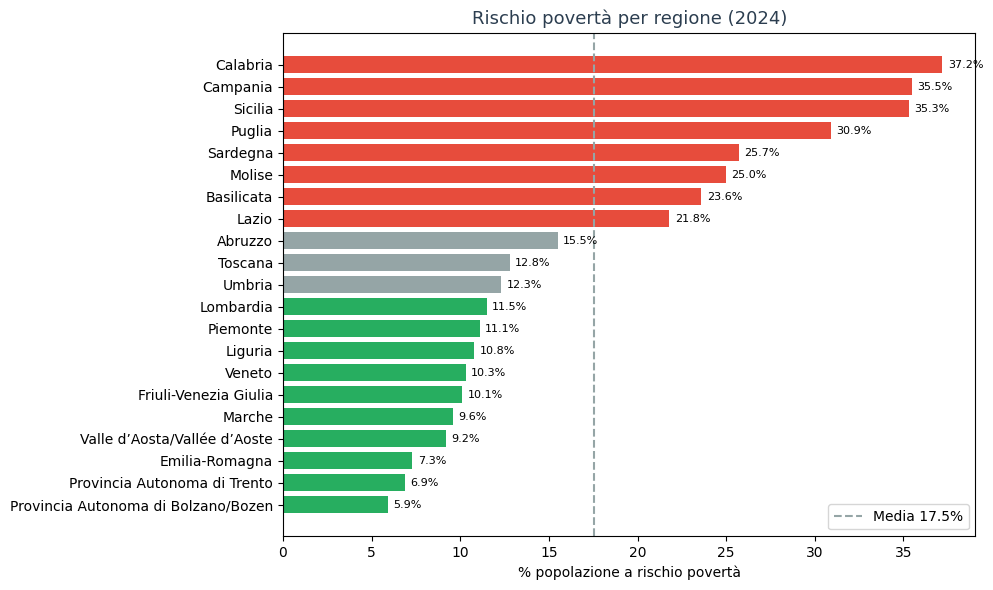

Gap: 37.2% / 5.9% = 6.3×


In [3]:
pov = con.execute(f"""
    SELECT geo_label_en, ROUND(value, 1) AS poverty_pct
    FROM read_parquet('{p('eurostat_poverty_risk_nuts2')}')
    WHERE unit='PC' AND year=2024 AND nuts_level='NUTS2' AND geo LIKE 'IT%'
    ORDER BY value
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if v > 20 else (GREEN if v < 12 else GRAY) for v in pov['poverty_pct']]
ax.barh(pov['geo_label_en'], pov['poverty_pct'], color=colors)
for _, r in pov.iterrows():
    ax.text(r['poverty_pct']+0.3, r.name, f'{r["poverty_pct"]}%', va='center', fontsize=8)
ax.axvline(x=pov['poverty_pct'].mean(), color=GRAY, linestyle='--',
           label=f'Media {pov["poverty_pct"].mean():.1f}%')
ax.set_xlabel('% popolazione a rischio povertà')
ax.set_title('Rischio povertà per regione (2024)', fontsize=13, color=BLUE)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS/'divario-nord-sud_poverty.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gap: {pov['poverty_pct'].max():.1f}% / {pov['poverty_pct'].min():.1f}% = {pov['poverty_pct'].max()/pov['poverty_pct'].min():.1f}×")

### 3. Sanità: medici vs posti letto (scatter plot, 2021)

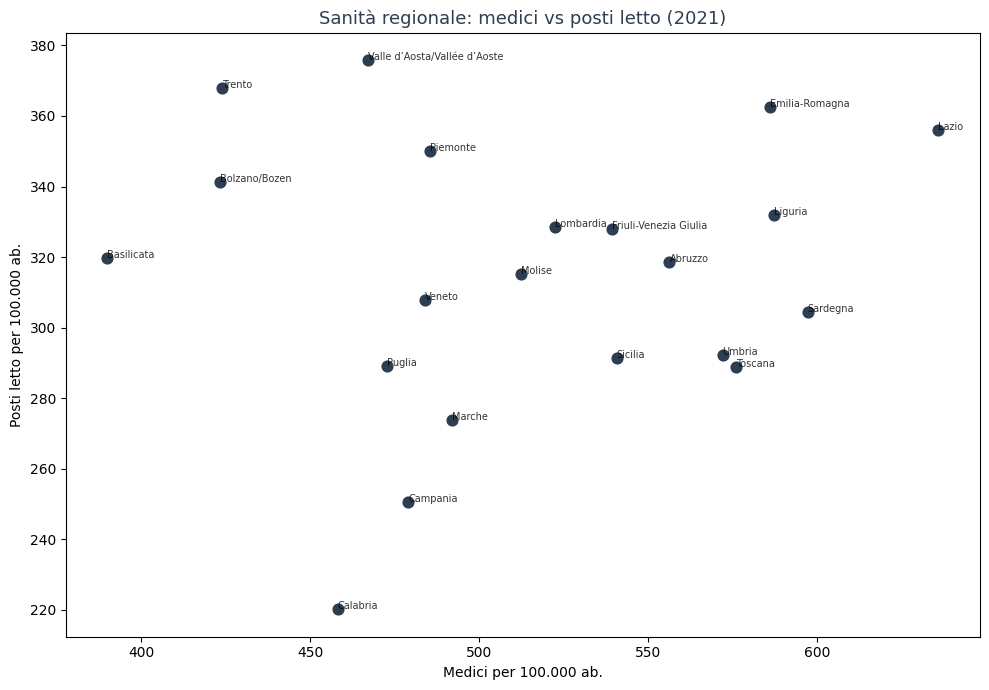

In [4]:
phys = con.execute(f"""
    SELECT geo_label_en, ROUND(value, 1) AS medici
    FROM read_parquet('{p('eurostat_physicians_nuts2')}')
    WHERE unit='P_HTHAB' AND year=2021 AND nuts_level='NUTS2' AND geo LIKE 'IT%'
""").fetchdf()

beds = con.execute(f"""
    SELECT geo_label_en, ROUND(value, 1) AS posti_letto
    FROM read_parquet('{p('eurostat_hospital_beds_nuts2')}')
    WHERE unit='P_HTHAB' AND year=2021 AND nuts_level='NUTS2' AND geo LIKE 'IT%'
""").fetchdf()

health = phys.merge(beds, on='geo_label_en')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(health['medici'], health['posti_letto'], c=BLUE, s=60)
for _, row in health.iterrows():
    label = row['geo_label_en'].replace('Provincia Autonoma di ','')
    ax.annotate(label, (row['medici'], row['posti_letto']), fontsize=7, alpha=0.8)
ax.set_xlabel('Medici per 100.000 ab.')
ax.set_ylabel('Posti letto per 100.000 ab.')
ax.set_title('Sanità regionale: medici vs posti letto (2021)', fontsize=13, color=BLUE)
plt.tight_layout()
plt.savefig(FIGS/'divario-nord-sud_health.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Età mediana per regione (2025)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

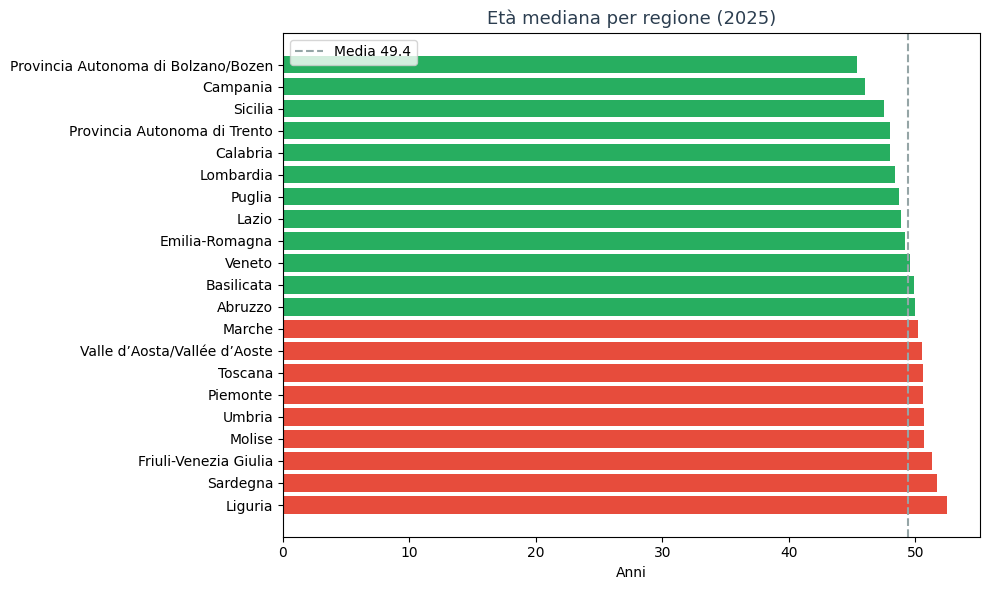

In [5]:
age = con.execute(f"""
    SELECT geo_label_en, ROUND(AVG(value), 1) AS eta_mediana
    FROM read_parquet('{p('eurostat_pop_structure_nuts3')}')
    WHERE indic_de='MEDAGEPOP' AND unit='YR' AND nuts_level='NUTS2'
      AND geo LIKE 'IT%' AND year=2025
    GROUP BY geo_label_en ORDER BY eta_mediana DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if v > 50 else GREEN for v in age['eta_mediana']]
ax.barh(age['geo_label_en'], age['eta_mediana'], color=colors)
ax.axvline(x=age['eta_mediana'].mean(), color=GRAY, linestyle='--',
           label=f'Media {age["eta_mediana"].mean():.1f}')
ax.set_xlabel('Anni')
ax.set_title('Età mediana per regione (2025)', fontsize=13, color=BLUE)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS/'divario-nord-sud_age.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Abbandono scolastico per regione (2024)

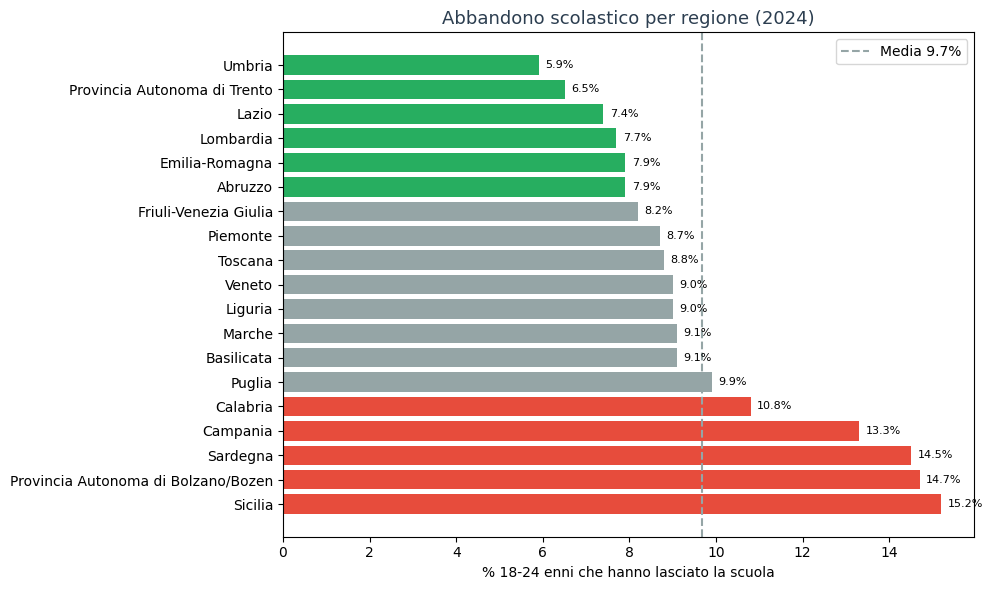

In [6]:
edu = con.execute(f"""
    SELECT geo_label_en, ROUND(value, 1) AS abbandono_pct
    FROM read_parquet('{p("eurostat_early_school_leavers_nuts2")}')
    WHERE unit='PC' AND sex='T' AND year=2024 AND nuts_level='NUTS2' AND geo LIKE 'IT%'
      AND value IS NOT NULL
    ORDER BY value DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if v > 10 else (GREEN if v < 8 else GRAY) for v in edu["abbandono_pct"]]
ax.barh(edu["geo_label_en"], edu["abbandono_pct"], color=colors)
for _, r in edu.iterrows():
    ax.text(r["abbandono_pct"]+0.15, r.name, f'{r["abbandono_pct"]}%', va="center", fontsize=8)
ax.axvline(x=edu['abbandono_pct'].mean(), color=GRAY, linestyle='--',
           label=f'Media {edu['abbandono_pct'].mean():.1f}%')
ax.set_xlabel('% 18-24 enni che hanno lasciato la scuola')
ax.set_title('Abbandono scolastico per regione (2024)', fontsize=13, color=BLUE)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS/'divario-nord-sud_education.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Riepilogo — gap per dimensione

In [7]:
print("Divario Nord-Sud per dimensione:\n")
print(f"PIL pro-capite:     {g_start:,.0f}€ (2000) → {g_end:,.0f}€ (2024)")
print(f"Povertà:            {pov['poverty_pct'].max():.1f}% / {pov['poverty_pct'].min():.1f}% = {pov['poverty_pct'].max()/pov['poverty_pct'].min():.1f}×")
print(f"Età mediana:        {age['eta_mediana'].max():.1f} / {age['eta_mediana'].min():.1f} anni")

Divario Nord-Sud per dimensione:

PIL pro-capite:     11,200€ (2000) → 19,025€ (2024)
Povertà:            37.2% / 5.9% = 6.3×
Età mediana:        52.5 / 45.4 anni
